In [1]:
import pandas as pd

df = pd.read_csv("D:/Data_Analysis/DA_portfolio/covid_19.csv")

print(df.info())
print(df.describe(include='all'))

<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     238 non-null    str    
 1   continent   236 non-null    str    
 2   population  229 non-null    float64
 3   day         238 non-null    str    
 4   time        238 non-null    str    
 5   Cases       238 non-null    int64  
 6   Recovered   190 non-null    float64
 7   Deaths      233 non-null    float64
 8   Tests       213 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 16.9 KB
None
             country continent    population         day  \
count            238       236  2.290000e+02         238   
unique           238         7           NaN           1   
top     Saint-Helena    Africa           NaN  2024-06-30   
freq               1        59           NaN         238   
mean             NaN       NaN  3.469404e+07         NaN   
std              NaN       NaN  

In [2]:
print(df.dtypes)

country           str
continent         str
population    float64
day               str
time              str
Cases           int64
Recovered     float64
Deaths        float64
Tests         float64
dtype: object


In [3]:
df.head

<bound method NDFrame.head of               country      continent   population         day  \
0        Saint-Helena         Africa       6115.0  2024-06-30   
1    Falkland-Islands  South-America       3539.0  2024-06-30   
2          Montserrat  North-America       4965.0  2024-06-30   
3    Diamond-Princess            NaN          NaN  2024-06-30   
4        Vatican-City         Europe        799.0  2024-06-30   
..                ...            ...          ...         ...   
233         Argentina  South-America   46010234.0  2024-06-30   
234       Netherlands         Europe   17211447.0  2024-06-30   
235            Mexico  North-America  131562772.0  2024-06-30   
236              Iran           Asia   86022837.0  2024-06-30   
237         Indonesia           Asia  279134505.0  2024-06-30   

                          time     Cases  Recovered    Deaths        Tests  
0    2024-06-30T16:15:16+00:00      2166        2.0       NaN          NaN  
1    2024-06-30T16:15:16+00:00     

In [4]:
df.tail

<bound method NDFrame.tail of               country      continent   population         day  \
0        Saint-Helena         Africa       6115.0  2024-06-30   
1    Falkland-Islands  South-America       3539.0  2024-06-30   
2          Montserrat  North-America       4965.0  2024-06-30   
3    Diamond-Princess            NaN          NaN  2024-06-30   
4        Vatican-City         Europe        799.0  2024-06-30   
..                ...            ...          ...         ...   
233         Argentina  South-America   46010234.0  2024-06-30   
234       Netherlands         Europe   17211447.0  2024-06-30   
235            Mexico  North-America  131562772.0  2024-06-30   
236              Iran           Asia   86022837.0  2024-06-30   
237         Indonesia           Asia  279134505.0  2024-06-30   

                          time     Cases  Recovered    Deaths        Tests  
0    2024-06-30T16:15:16+00:00      2166        2.0       NaN          NaN  
1    2024-06-30T16:15:16+00:00     

In [5]:
# Check null values
print(df.isnull().sum())

# Drop rows with too many nulls OR fill them
df = df.dropna()   # simple approach

country        0
continent      2
population     9
day            0
time           0
Cases          0
Recovered     48
Deaths         5
Tests         25
dtype: int64


In [6]:
total_cases = df["Cases"].sum()
total_deaths = df["Deaths"].sum()
total_recovered = df["Recovered"].sum()
total_tests = df["Tests"].sum()

print("Total Cases:", total_cases)
print("Total Deaths:", total_deaths)
print("Total Recovered:", total_recovered)
print("Total Tests:", total_tests)

Total Cases: 567597278
Total Deaths: 5809722.0
Total Recovered: 555690895.0
Total Tests: 5262879273.0


In [8]:
country_data = df.groupby("country").agg({
    "Cases": "sum",
    "Deaths": "sum",
    "Recovered": "sum",
    "Tests": "sum",
    "population": "first"
})

print(country_data)

                        Cases   Deaths   Recovered       Tests  population
country                                                                   
Afghanistan            234174   7996.0    211080.0   1390730.0  40754388.0
Albania                334863   3605.0    330233.0   1941032.0   2866374.0
Algeria                272010   6881.0    183061.0    230960.0  45350148.0
Angola                 107327   1937.0    103419.0   1499795.0  35027343.0
Antigua-and-Barbuda      9106    146.0      8954.0     18901.0     99509.0
...                       ...      ...         ...         ...         ...
Vietnam              11625195  43206.0  10640971.0  85826548.0  98953541.0
Wallis-and-Futuna        3550      8.0       438.0     20508.0     10982.0
Yemen                   11945   2159.0      9124.0    329592.0  31154867.0
Zambia                 349304   4069.0    341316.0   4112961.0  19470234.0
Zimbabwe               266359   5740.0    258888.0   2525756.0  15331428.0

[169 rows x 5 columns]


In [9]:
top_cases = country_data.sort_values(by="Cases", ascending=False).head(10)
print(top_cases)

               Cases     Deaths    Recovered         Tests   population
country                                                                
USA        111820082  1219487.0  109814428.0  1.186852e+09  334805269.0
France      40138560   167642.0   39970918.0  2.714902e+08   65584518.0
Germany     38828995   183027.0   38240600.0  1.223324e+08   83883596.0
Brazil      38743918   711380.0   36249161.0  6.377617e+07  215353593.0
S-Korea     34571873    35934.0   34535939.0  1.580406e+07   51329899.0
Italy       26723249   196487.0   26361218.0  2.811264e+08   60262770.0
UK          24910387   232112.0   24678275.0  5.225265e+08   68497907.0
Russia      24124215   402756.0   23545818.0  2.734000e+08  145805947.0
Spain       13914811   121760.0   13762417.0  4.710363e+08   46719142.0
Australia   11853144    24414.0   11820014.0  8.191664e+07   26068792.0


In [10]:
country_data["Death Rate (%)"] = (country_data["Deaths"] / country_data["Cases"]) * 100
country_data["Recovery Rate (%)"] = (country_data["Recovered"] / country_data["Cases"]) * 100

print(country_data)

                        Cases   Deaths   Recovered       Tests  population  \
country                                                                      
Afghanistan            234174   7996.0    211080.0   1390730.0  40754388.0   
Albania                334863   3605.0    330233.0   1941032.0   2866374.0   
Algeria                272010   6881.0    183061.0    230960.0  45350148.0   
Angola                 107327   1937.0    103419.0   1499795.0  35027343.0   
Antigua-and-Barbuda      9106    146.0      8954.0     18901.0     99509.0   
...                       ...      ...         ...         ...         ...   
Vietnam              11625195  43206.0  10640971.0  85826548.0  98953541.0   
Wallis-and-Futuna        3550      8.0       438.0     20508.0     10982.0   
Yemen                   11945   2159.0      9124.0    329592.0  31154867.0   
Zambia                 349304   4069.0    341316.0   4112961.0  19470234.0   
Zimbabwe               266359   5740.0    258888.0   2525756.0  

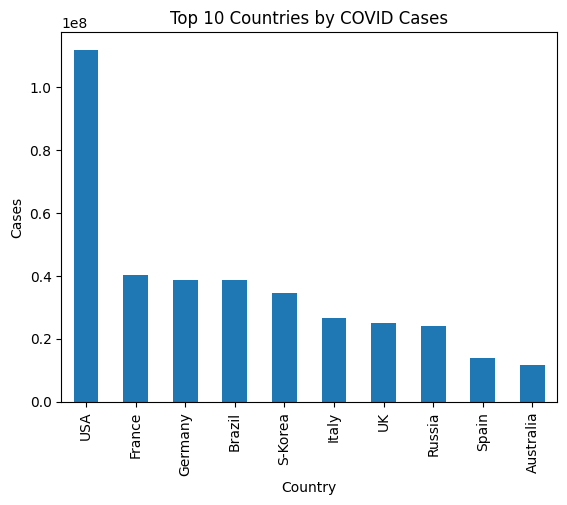

In [11]:
import matplotlib.pyplot as plt

top_cases["Cases"].plot(kind='bar')
plt.title("Top 10 Countries by COVID Cases")
plt.xlabel("Country")
plt.ylabel("Cases")
plt.show()

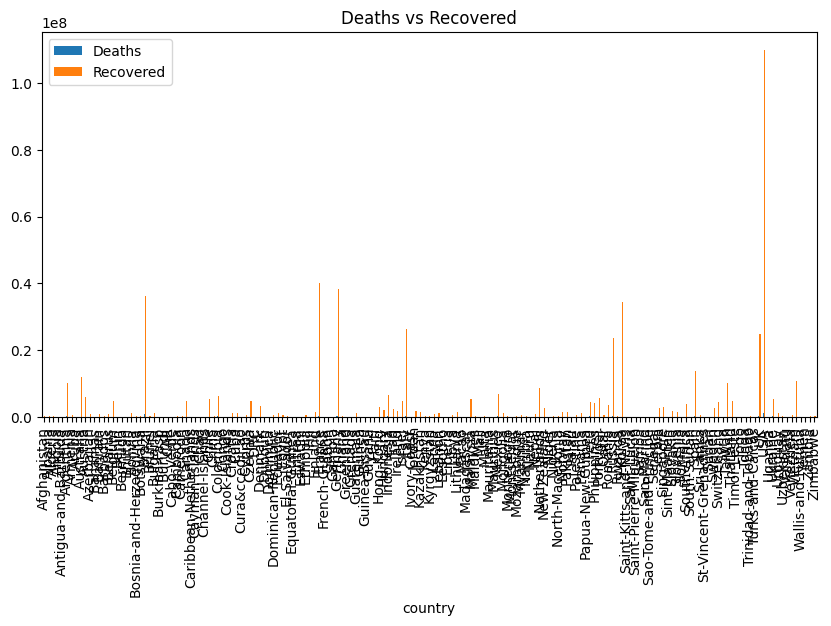

In [12]:
country_data[["Deaths", "Recovered"]].plot(kind='bar', figsize=(10,5))
plt.title("Deaths vs Recovered")
plt.show()

In [13]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Example: Predict Cases based on Tests
X = df[["Tests"]]
y = df["Cases"]

model = LinearRegression()
model.fit(X, y)

# Predict
predicted_cases = model.predict(X)

df["Predicted Cases"] = predicted_cases
print(df.head())

                  country      continent    population         day  \
2              Montserrat  North-America  4.965000e+03  2024-06-30   
7                   China           Asia  1.448471e+09  2024-06-30   
9   Saint-Pierre-Miquelon  North-America  5.759000e+03  2024-06-30   
14               Djibouti         Africa  1.016097e+06  2024-06-30   
15              Greenland  North-America  5.697300e+04  2024-06-30   

                         time   Cases  Recovered  Deaths        Tests  \
2   2024-06-30T16:15:16+00:00    1403     1376.0     8.0      17762.0   
7   2024-06-30T16:15:16+00:00  503302   379053.0  5272.0  160000000.0   
9   2024-06-30T16:15:16+00:00    3452     2449.0     2.0      25400.0   
14  2024-06-30T16:15:15+00:00   15690    15427.0   189.0     305941.0   
15  2024-06-30T16:15:15+00:00   11971     2761.0    21.0     164926.0   

    Predicted Cases  
2      7.903064e+05  
7      1.399175e+07  
9      7.909367e+05  
14     8.140864e+05  
15     8.024501e+05  


In [14]:
top_cases = country_data.sort_values(by="Cases", ascending=False).head(10)
print(top_cases)

               Cases     Deaths    Recovered         Tests   population  \
country                                                                   
USA        111820082  1219487.0  109814428.0  1.186852e+09  334805269.0   
France      40138560   167642.0   39970918.0  2.714902e+08   65584518.0   
Germany     38828995   183027.0   38240600.0  1.223324e+08   83883596.0   
Brazil      38743918   711380.0   36249161.0  6.377617e+07  215353593.0   
S-Korea     34571873    35934.0   34535939.0  1.580406e+07   51329899.0   
Italy       26723249   196487.0   26361218.0  2.811264e+08   60262770.0   
UK          24910387   232112.0   24678275.0  5.225265e+08   68497907.0   
Russia      24124215   402756.0   23545818.0  2.734000e+08  145805947.0   
Spain       13914811   121760.0   13762417.0  4.710363e+08   46719142.0   
Australia   11853144    24414.0   11820014.0  8.191664e+07   26068792.0   

           Death Rate (%)  Recovery Rate (%)  
country                                       
USA  

In [17]:

country_data["Death Rate (%)"] = (country_data["Deaths"] / country_data["Cases"]) * 100

In [18]:
country_data["Recovery Rate (%)"] = (country_data["Recovered"] / country_data["Cases"]) * 100

<Axes: xlabel='Tests', ylabel='Cases'>

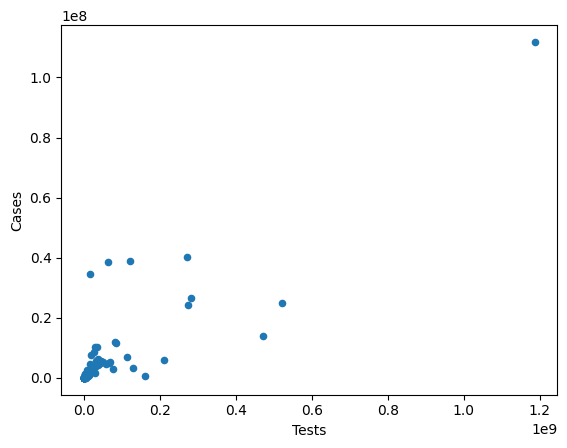

In [19]:
df.plot(x="Tests", y="Cases", kind="scatter")